In [55]:
#IMPORTING LIBRARIES

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [56]:
#LOAD DATASET

data=pd.read_csv("C:\\leadsense-ai\\backend\\data\\synthetic_leads.csv")
print("data_shape:",data.shape)
data.head()

data_shape: (5000, 16)


,age,income,budget,credit_score,income_confidence,user_segment,pages_viewed,time_on_site,return_visits,session_count,contact_form_submitted,downloaded_brochure,property_saved,chat_with_agent,traffic_source,converted
0,59,81158,345238,584,0.66,curious_researcher,5,196,3,4,1,0,0,0,facebook_ads,0
1,49,54782,205628,522,0.47,serious_buyer,13,782,7,8,0,0,0,0,google_ads,0
2,35,105709,418787,565,0.67,curious_researcher,9,214,1,3,0,0,0,0,google_ads,0
3,28,98533,335498,672,0.48,serious_buyer,17,807,3,9,1,0,0,0,organic_search,1
4,41,128939,501383,532,0.71,curious_researcher,7,295,2,4,1,0,1,0,referral,0


In [57]:
#CHECK DATA

data.info()

data.describe()

data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   income                  5000 non-null   int64  
 2   budget                  5000 non-null   int64  
 3   credit_score            5000 non-null   int64  
 4   income_confidence       5000 non-null   float64
 5   user_segment            5000 non-null   object 
 6   pages_viewed            5000 non-null   int64  
 7   time_on_site            5000 non-null   int64  
 8   return_visits           5000 non-null   int64  
 9   session_count           5000 non-null   int64  
 10  contact_form_submitted  5000 non-null   int64  
 11  downloaded_brochure     5000 non-null   int64  
 12  property_saved          5000 non-null   int64  
 13  chat_with_agent         5000 non-null   int64  
 14  traffic_source          5000 non-null   

age                       0
income                    0
budget                    0
credit_score              0
income_confidence         0
user_segment              0
pages_viewed              0
time_on_site              0
return_visits             0
session_count             0
contact_form_submitted    0
downloaded_brochure       0
property_saved            0
chat_with_agent           0
traffic_source            0
converted                 0
dtype: int64

In [58]:
#ENCODE CATEGORICAL FEATURES

label_encoder=LabelEncoder()

data["traffic_source"]=label_encoder.fit_transform(data["traffic_source"])
data["user_segment"]=label_encoder.fit_transform(data["user_segment"])


In [59]:
#SPLIT FEATURES AND TARGET
x=data.drop("converted",axis=1)
y=data["converted"]
print(*"feature shape:",x.shape)

f e a t u r e   s h a p e : (5000, 15)


In [60]:
#TRAIN/TEST SPLIT
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training data:",x_train.shape)
print("Testing data:",x_test.shape)

Training data: (4000, 15)
Testing data: (1000, 15)


In [61]:
#BASELINE MODEL(Logistic Regression)
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(x_train, y_train)

baseline_preds = baseline_model.predict(x_test)

baseline_accuracy = accuracy_score(y_test, baseline_preds)

print("Baseline Logistic Regression Accuracy:", baseline_accuracy)


Baseline Logistic Regression Accuracy: 0.929


C:\Users\Dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [62]:
#TRAIN XGBOOST MODEL
model=xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subexample_bytree=0.8,
    randome_state=42
)

model.fit(x_train,y_train)
print("model training complete")

C:\Users\Dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [12:07:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "randome_state", "subexample_bytree" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


model training complete


In [63]:
#PREDICTIONS
predictions=model.predict(x_test)
probabilities=model.predict_proba(x_test)[:,1]

In [64]:
#ACCURACY
accuracy=accuracy_score(y_test,predictions)
print("model accuracy:",accuracy)

model accuracy: 0.976


In [65]:
#CLASSIFICATION REPORT
print(classification_report(y_test,predictions))


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       885
           1       0.91      0.88      0.89       115

    accuracy                           0.98      1000
   macro avg       0.95      0.93      0.94      1000
weighted avg       0.98      0.98      0.98      1000



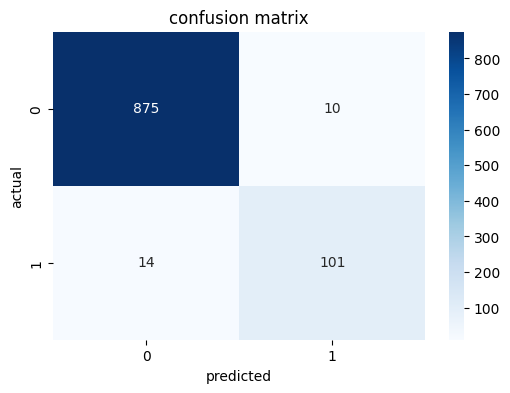

In [66]:
#CONFUSION MATRIX
cm=confusion_matrix(y_test,predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

In [67]:
#ROC AUC SCORE
roc_score=roc_auc_score(y_test,probabilities)
print("ROC AUC Score:",roc_score)

ROC AUC Score: 0.9970621468926554


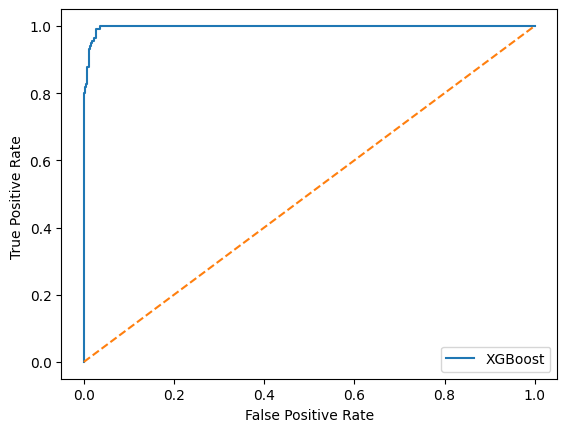

In [68]:
#ROC CURVE
fpr,tpr,_=roc_curve(y_test,probabilities)
plt.plot(fpr,tpr,label="XGBoost")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate ")
plt.legend()
plt.show()

In [69]:
#CROSS VALIDATION
scores=cross_val_score(model,x,y,cv=5)
print("Cross Validation Scores:",scores)
print("Average CV Scores:",scores.mean())

C:\Users\Dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [12:07:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "randome_state", "subexample_bytree" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [12:07:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "randome_state", "subexample_bytree" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [12:07:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters:

Cross Validation Scores: [0.98  0.975 0.971 0.981 0.975]
Average CV Scores: 0.9763999999999999


C:\Users\Dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [12:07:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "randome_state", "subexample_bytree" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


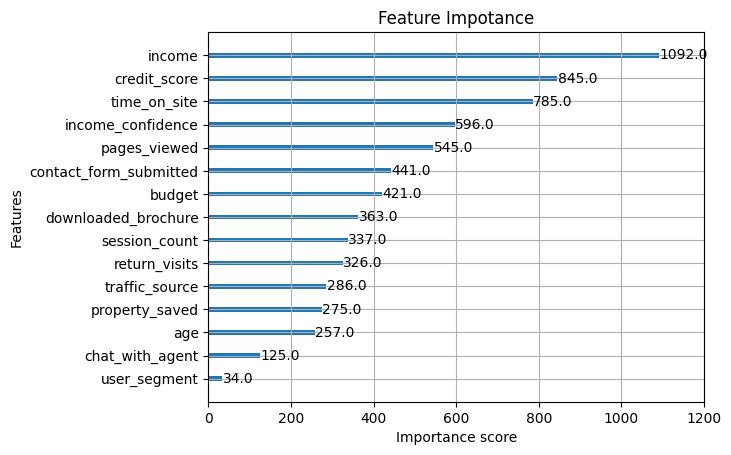

In [70]:
#FEATURE IMPORTANCE
xgb.plot_importance(model)
plt.title("Feature Impotance")
plt.show()

In [71]:
#Sve Trained Model
joblib.dump(model,"../backend/models/leadsense_xgb.pkl")
print("Model Sved Successfully!")


Model Sved Successfully!
